
# Семинар: Линейная регрессия. Задачи

### Задание: Линейная регрессия.

В этом задании мы рассмотрим метод линейной регрессии (метод наименьших квадратов - МНК). Мы будем работать с наборов данных, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score

In [16]:
from google.colab import files
upload = files.upload()

Saving diamonds.csv to diamonds (1).csv


In [28]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 1.1.** Есть ли в наборе данных пропущенные значения? Если да, удалите их.

In [29]:
data.isnull().any()

,0
Unnamed: 0,False
carat,False
cut,False
color,False
clarity,False
depth,False
table,False
price,False
x,False
y,False


**Задача 1.2.** Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [30]:
del data["Unnamed: 0"]
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 1.3.** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Выведите матрицу выборочных корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки коррелируют с целевой переменной больше всего?

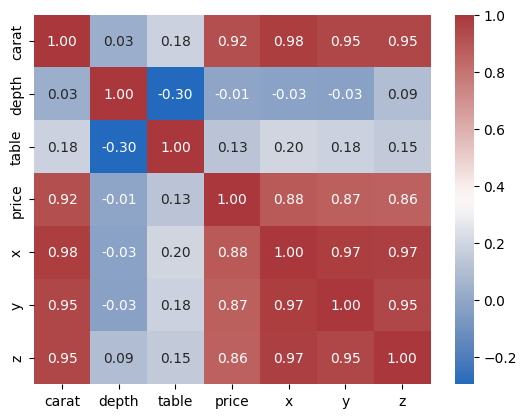

In [31]:
sns.heatmap(data.corr(numeric_only=True), cmap="vlag", annot=True, fmt="0.2f");

**Задача 1.4.** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные переменные при помощи OneHot-кодирования.

In [32]:
D_dum = pd.get_dummies(data, drop_first=True)
print(f"Data shape: {D_dum.shape}")
D_dum.head()

Data shape: (53940, 24)


,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False


**Задача 1.5.** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [33]:
from sklearn.model_selection import train_test_split
X = D_dum.drop(['table'],axis=1) #Особенности (все, кроме «таблицы»)
y = D_dum['table'] #Целевая переменная («таблица»)
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=400)
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (37758, 23)
X_test:  (16182, 23)
y_train:  (37758,)
y_test:  (16182,)


**Задача 1.6.** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче масштабируйте вещественные признаки тренировочной и тестовой выборок при помощи модуля `StandardScaler`.

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-0.39555832, -0.04043823, -0.04140244, ..., -0.54288375,
        -0.26997002,  3.10952015],
       [-0.5225311 , -2.54555156, -0.58589027, ...,  1.84201498,
        -0.26997002, -0.32159303],
       [ 0.57789968,  0.72501307,  0.24502477, ..., -0.54288375,
        -0.26997002, -0.32159303],
       ...,
       [ 1.48787129,  5.24813436, -0.18775394, ..., -0.54288375,
        -0.26997002, -0.32159303],
       [-0.16277488, -0.875476  , -0.12901251, ..., -0.54288375,
        -0.26997002, -0.32159303],
       [-0.16277488,  1.21211844, -0.30699401, ...,  1.84201498,
        -0.26997002, -0.32159303]])

**Задача 1.7.** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [35]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)
# Рассчитайте среднеквадратическую ошибку для обучающих и тестовых наборов
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
# Вычисление среднеквадратической ошибки (RMSE) для обучающих и тестовых наборов
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Рассчитайте среднюю абсолютную ошибку (MAE) для обучающих и тестовых наборов.
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print('mse_train: ', mse_train)
print('mse_test: ', mse_test, '\n')
print('rmse_train: ', rmse_train)
print('rmse_test: ', rmse_test, '\n')
print('mae_train: ', mae_train)
print('mae_test: ', mae_test, '\n')

mse_train:  1484.9272430451651
mse_test:  1484.514380410349 

rmse_train:  38.534753704223476
rmse_test:  38.5293963151559 

mae_train:  38.46280167260394
mae_test:  38.45640610421478 



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Задача 1.8.** Изучите документацию модуля `LinearRegression` и выведите полученные оценки коэффициентов (весов). Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [36]:
lr.intercept_

95.91514819519517

In [37]:
pd.DataFrame(lr.coef_, X.columns, columns=["coef"]).sort_values(by="coef", ascending=False)

,coef
carat,1.514918
x,0.840430
clarity_VS2,0.139973
z,0.138422
clarity_SI1,0.135548
clarity_VS1,0.122986
clarity_VVS2,0.116901
clarity_VVS1,0.104456
clarity_SI2,0.091914
color_E,0.038207


In [38]:
reg = LinearRegression().fit(X_train, y_train)
print('reg.score: ',reg.score(X_test, y_test))
print('\n',reg.coef_)

reg.score:  0.4051027184261239

 [ 1.51491794e+00 -5.77001087e-01 -7.03545643e-05  8.40429995e-01
 -1.14706438e+00  1.38422254e-01 -1.01892125e+00 -4.00238930e+00
 -1.62247118e+00 -2.00268712e+00  3.82074543e-02 -8.02128281e-02
 -9.02464941e-02 -9.45155668e-02 -7.78269363e-02 -9.40978346e-02
  6.94169320e-03  1.35548084e-01  9.19144038e-02  1.22985907e-01
  1.39972555e-01  1.04456054e-01  1.16901213e-01]


**Задача 1.9.** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, *между некоторыми признаками* имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности* (наличия линейной зависимости между объясняющими переменными (факторами) модели). Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно   
*либо исключить некоторые признаки из модели*,  
*либо использовать регуляризацию*.   
Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \frac{1}{2}\alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Выберите два признака, сильно коррелирующих между собой, и постройте зависимость (scatter) одного от другого.

Обучите Lasso-регрессию и Ridge-регрессию, уставновив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [39]:
#Проверка корреляций между двумя признаками
X.corr()

,carat,depth,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
carat,1.000000,0.028224,0.921591,0.975094,0.951722,0.953387,0.034196,-0.163660,0.116245,0.009568,...,0.102465,0.161494,0.180054,-0.114449,0.062669,0.267483,-0.063094,-0.038904,-0.167571,-0.137024
depth,0.028224,1.000000,-0.010647,-0.025289,-0.029341,0.094924,0.136114,-0.022778,-0.198306,0.025828,...,0.026037,0.022630,0.022543,-0.030881,0.040899,0.007202,-0.024169,-0.009459,-0.023477,-0.019243
price,0.921591,-0.010647,1.000000,0.884435,0.865421,0.861249,-0.000312,-0.097175,0.095706,0.006593,...,0.059223,0.097125,0.081710,-0.049596,0.008957,0.128420,-0.009886,-0.001062,-0.095266,-0.052381
x,0.975094,-0.025289,0.884435,1.000000,0.974701,0.970772,0.030349,-0.162674,0.126820,0.004569,...,0.095896,0.146522,0.164658,-0.125976,0.079241,0.270827,-0.059882,-0.035507,-0.185253,-0.147151
y,0.951722,-0.029341,0.865421,0.974701,1.000000,0.952006,0.032187,-0.153158,0.107943,0.016699,...,0.093480,0.142895,0.160776,-0.120800,0.076097,0.263252,-0.056490,-0.035928,-0.179271,-0.141624
z,0.953387,0.094924,0.861249,0.970772,0.952006,1.000000,0.045169,-0.158688,0.090019,0.016039,...,0.095041,0.145276,0.164217,-0.125248,0.081005,0.263192,-0.058513,-0.036314,-0.182401,-0.144746
cut_Good,0.034196,0.136114,-0.000312,0.030349,0.032187,0.045169,1.000000,-0.258018,-0.185385,-0.169940,...,-0.009517,0.006187,0.014977,-0.033046,0.055938,0.041970,-0.017116,-0.021063,-0.037564,-0.038627
cut_Ideal,-0.163660,-0.022778,-0.097175,-0.162674,-0.153158,-0.158688,-0.258018,1.000000,-0.478074,-0.438243,...,-0.021264,-0.009225,-0.038490,0.104986,-0.082865,-0.108242,0.034247,0.015669,0.088354,0.075508
cut_Premium,0.116245,-0.198306,0.095706,0.126820,0.107943,0.090019,-0.185385,-0.478074,1.000000,-0.314877,...,0.027895,0.005899,0.017231,-0.054013,0.023275,0.067623,-0.011866,0.022611,-0.053852,-0.061949
cut_Very Good,0.009568,0.025828,0.006593,0.004569,0.016699,0.016039,-0.169940,-0.438243,-0.314877,1.000000,...,-0.004437,-0.001549,0.009816,-0.033003,0.032547,0.004806,-0.006849,-0.016412,-0.005251,0.015284


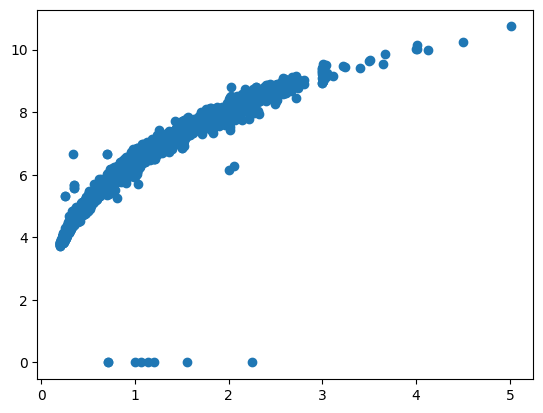

In [40]:
#постройка зависимость (scatter)
plt.scatter(X['carat'], X['x'])
plt.show()

In [49]:
#Обучите Lasso-регрессию
lasso = Lasso(10.0).fit(X_train, y_train)
print(f"lasso.Train: {mean_squared_error(y_train, lasso.predict(X_train))}")
print(f"lasso.Test: {mean_squared_error(y_test, lasso.predict(X_test))}")
print(lasso.coef_)

lasso.Train: 4.880281191140015
lasso.Test: 4.986610532977544
[ 0.00000000e+00 -0.00000000e+00  7.05445081e-05  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]


In [48]:
pd.DataFrame(lasso.coef_, X.columns, columns=["coef"]).sort_values(by="coef", ascending=False)

,coef
price,0.000071
carat,0.000000
color_G,-0.000000
clarity_VVS1,-0.000000
clarity_VS2,-0.000000
clarity_VS1,-0.000000
clarity_SI2,0.000000
clarity_SI1,0.000000
clarity_IF,-0.000000
color_J,0.000000


In [50]:
#Обучите Ridge-регрессию
ridge = Ridge(10.0).fit(X_train, y_train)
print(f"ridge.Train: {mean_squared_error(y_train, lasso.predict(X_train))}")
print(f"ridge.Test: {mean_squared_error(y_test, lasso.predict(X_test))}")
print(ridge.coef_)

ridge.Train: 4.880281191140015
ridge.Test: 4.986610532977544
[ 1.44742357e+00 -5.72827080e-01 -6.81037783e-05  7.61932533e-01
 -1.04773409e+00  1.37880638e-01 -9.41209485e-01 -3.92229998e+00
 -1.53815181e+00 -1.92488399e+00  3.93805830e-02 -7.85818306e-02
 -8.82732927e-02 -9.02708859e-02 -7.24295667e-02 -8.52763848e-02
 -3.76732961e-02  9.48425442e-02  5.61569715e-02  7.97507342e-02
  9.78910548e-02  6.03245751e-02  7.28623933e-02]


In [51]:
pd.DataFrame(ridge.coef_, X.columns, columns=["coef"]).sort_values(by="coef", ascending=False)

,coef
carat,1.447424
x,0.761933
z,0.137881
clarity_VS2,0.097891
clarity_SI1,0.094843
clarity_VS1,0.079751
clarity_VVS2,0.072862
clarity_VVS1,0.060325
clarity_SI2,0.056157
color_E,0.039381


В регрессии Лассо различия в весах весьма выражены. Когда только несколько переменных-предикторов действительно значимы, регрессия Лассо часто работает лучше, поскольку она может полностью свести коэффициенты несущественных переменных к нулю, эффективно удаляя их из модели, как это наблюдается здесь. Независимо от выбранного метода регрессии веса переменных либо существенно увеличивались, либо уменьшались, что указывает на наличие мультиколлинеарности.



**Задача 3.10** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее уменьшает веса?

lasso0


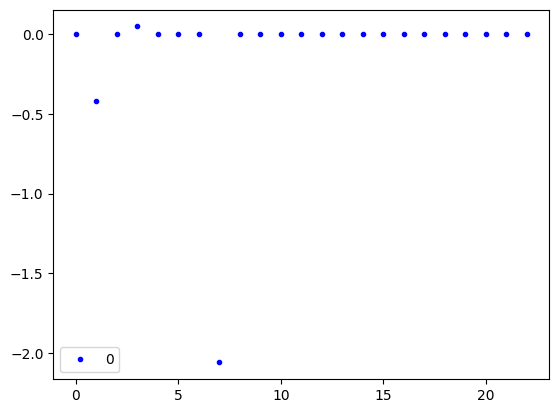

In [55]:
#обучиние Lasso-регрессии и постройка график
lasso0 = Lasso(0.1).fit(X_train, y_train)
print("lasso0")
pd.DataFrame(lasso0.coef_).plot(style='.', color='blue');

Ridge0


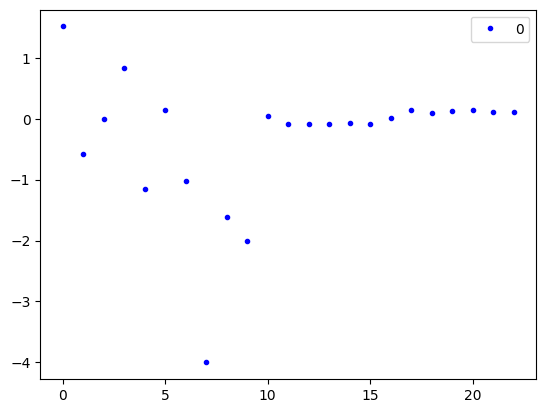

In [64]:
#обучиние Ridge-регрессии и постройка график
ridge0 = Ridge(0.1).fit(X_train, y_train)
print("Ridge0")
pd.DataFrame(ridge0.coef_).plot(style='.', color='blue');

In [57]:
#евклидова нормы весов (np.linalg.norm() от вектора оценок коэффициентов) в зависимости от параметра 0.1
print("np.linalg.norm for reg.coef_:",np.linalg.norm(reg.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_lasso1:",np.linalg.norm(lasso0.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_ridge1:",np.linalg.norm(ridge0.coef_, ord=None, axis=None, keepdims=False))

np.linalg.norm for reg.coef_: 5.338134803997266
np.linalg.norm for weights_lasso1: 2.1022954685994915
np.linalg.norm for weights_ridge1: 5.336124809266969


lasso1


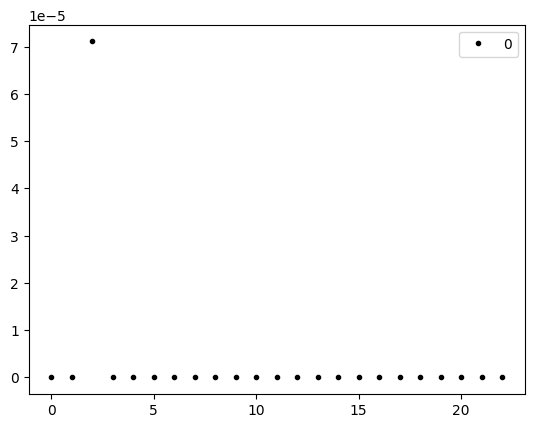

In [58]:
#обучиние Lasso-регрессии и постройка график
lasso1 = Lasso(1.0).fit(X_train, y_train)
print("lasso1")
pd.DataFrame(lasso1.coef_).plot(style='.', color='black');

Ridge1


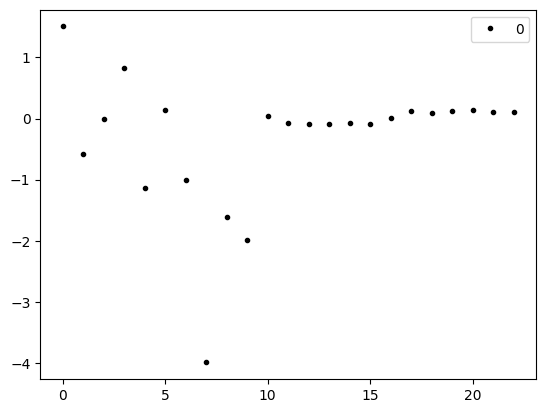

In [67]:
#обучиние Ridge-регрессии и постройка график
ridge1 = Ridge(1.0).fit(X_train, y_train)
print("Ridge1")
pd.DataFrame(ridge1.coef_).plot(style='.', color='black');

In [70]:
#евклидова нормы весов (np.linalg.norm() от вектора оценок коэффициентов) в зависимости от параметра 1.0
print("np.linalg.norm for reg.coef_:",np.linalg.norm(reg.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_lasso1:",np.linalg.norm(lasso1.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_ridge1:",np.linalg.norm(ridge1.coef_, ord=None, axis=None, keepdims=False))

np.linalg.norm for reg.coef_: 5.338134803997266
np.linalg.norm for weights_lasso1: 7.111166049265856e-05
np.linalg.norm for weights_ridge1: 5.318179949329675


lasso10


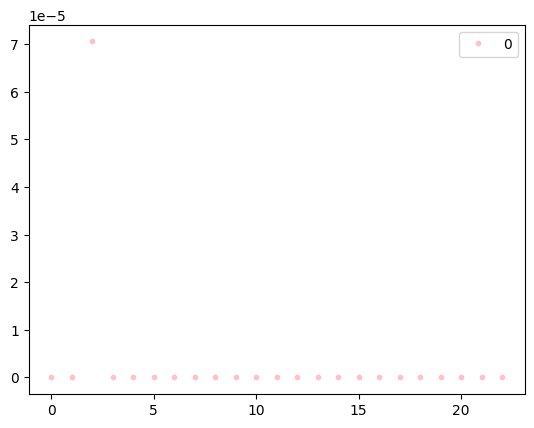

In [59]:
#обучиние Lasso-регрессии и постройка график
lasso10 = Lasso(10.0).fit(X_train, y_train)
print("lasso10")
pd.DataFrame(lasso10.coef_).plot(style='.', color='pink');

Ridge10


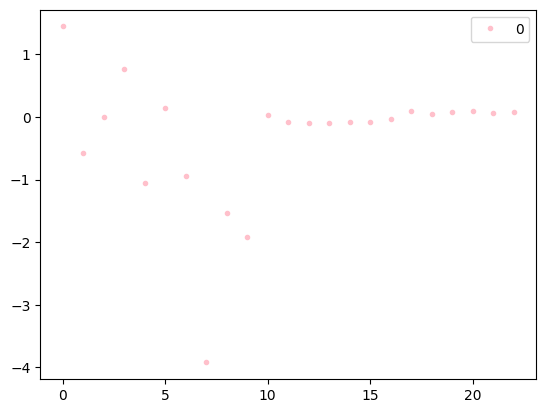

In [66]:
#обучиние Ridge-регрессии и постройка график
ridge10 = Ridge(10.0).fit(X_train, y_train)
print("Ridge10")
pd.DataFrame(ridge10.coef_).plot(style='.', color='pink');

In [71]:
#евклидова нормы весов (np.linalg.norm() от вектора оценок коэффициентов) в зависимости от параметра 10
print("np.linalg.norm for reg.coef_:",np.linalg.norm(reg.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_lasso1:",np.linalg.norm(lasso10.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_ridge1:",np.linalg.norm(ridge10.coef_, ord=None, axis=None, keepdims=False))

np.linalg.norm for reg.coef_: 5.338134803997266
np.linalg.norm for weights_lasso1: 7.054450810404343e-05
np.linalg.norm for weights_ridge1: 5.151360060502445


lasso100


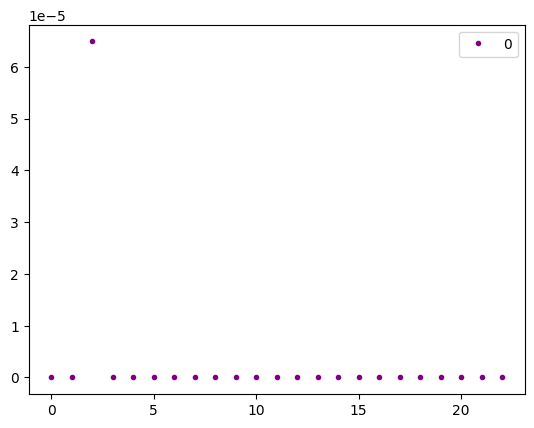

In [61]:
#обучиние Lasso-регрессии и постройка график
lasso100 = Lasso(100.0).fit(X_train, y_train)
print("lasso100")
pd.DataFrame(lasso100.coef_).plot(style='.', color='purple');

Ridge100


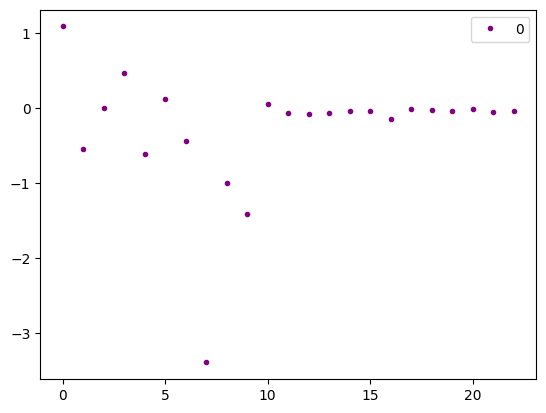

In [68]:
#обучиние Ridge-регрессии и постройка график
ridge100 = Ridge(100.0).fit(X_train, y_train)
print("Ridge100")
pd.DataFrame(ridge100.coef_).plot(style='.', color='purple');

In [72]:
#евклидова нормы весов (np.linalg.norm() от вектора оценок коэффициентов) в зависимости от параметра 100
print("np.linalg.norm for reg.coef_:",np.linalg.norm(reg.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_lasso1:",np.linalg.norm(lasso100.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_ridge1:",np.linalg.norm(ridge100.coef_, ord=None, axis=None, keepdims=False))

np.linalg.norm for reg.coef_: 5.338134803997266
np.linalg.norm for weights_lasso1: 6.487298421789204e-05
np.linalg.norm for weights_ridge1: 4.103165670249451


lasso200


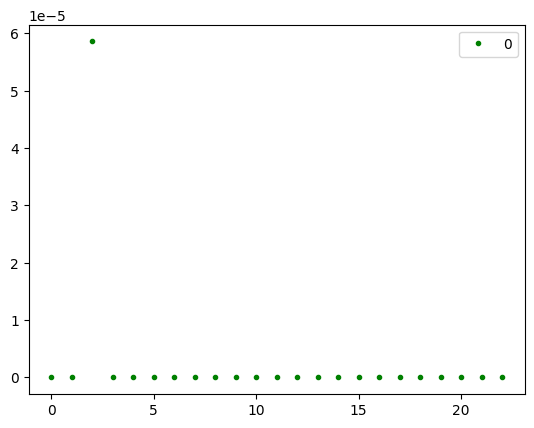

In [63]:
#обучиние Lasso-регрессии и постройка график
lasso200 = Lasso(200.0).fit(X_train, y_train)
print("lasso200")
pd.DataFrame(lasso200.coef_).plot(style='.', color='green');

Ridge200


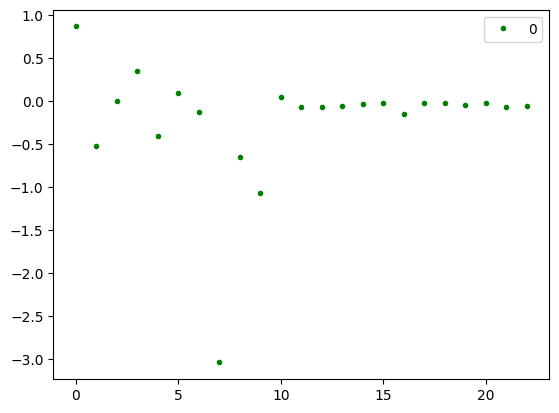

In [69]:
#обучиние Ridge-регрессии и постройка график
ridge200 = Ridge(200.0).fit(X_train, y_train)
print("Ridge200")
pd.DataFrame(ridge200.coef_).plot(style='.', color='green');

In [73]:
#евклидова нормы весов (np.linalg.norm() от вектора оценок коэффициентов) в зависимости от параметра 200
print("np.linalg.norm for reg.coef_:",np.linalg.norm(reg.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_lasso1:",np.linalg.norm(lasso200.coef_, ord=None, axis=None, keepdims=False))
print("np.linalg.norm for weights_ridge1:",np.linalg.norm(ridge200.coef_, ord=None, axis=None, keepdims=False))

np.linalg.norm for reg.coef_: 5.338134803997266
np.linalg.norm for weights_lasso1: 5.85712910110572e-05
np.linalg.norm for weights_ridge1: 3.4989733151387323


По мере увеличения параметров вес lasso-регрессии уменьшается, а вес ridge-регрессии уменьшается.
